In [34]:
from pathlib import Path
from dotenv import load_dotenv
import os
import sys

import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

In [29]:
load_dotenv()
DATA_DIR = Path(os.getenv("DATA_DIR"))

columns = [
    "gameid", "date", "league", "year", "split",
    "playoffs", "game", "patch", "side", "position",
    "teamname", "teamid", "result",
    "golddiffat15", "firstdragon", "firstherald",
    "firsttower", "datacompleteness",
]

frames = []

for year in [2025,2026]:
    path = DATA_DIR / (
        f"{year}_LoL_esports_match_data_from_OraclesElixir.csv"
    )

    raw = pd.read_csv(
        path,
        usecols = columns,
        low_memory = False
    )

    selected = raw.loc[
        (raw["league"] == "LCK")
        & (raw["position"] == "team")
        & (raw["datacompleteness"] == "complete")
    ]

    print(f"{year}: Entire {len(raw):,}rows → Selected {len(selected):,}rows")
    frames.append(selected)

team_games = pd.concat(frames, ignore_index=True)
team_games["date"] = pd.to_datetime(
    team_games["date"],
    errors="raise",
)

team_games = (
    team_games
    .sort_values(["date", "gameid", "side"])
    .reset_index(drop=True)
)

print("\nTeam Record:", len(team_games))
print("Set number:", team_games["gameid"].nunique())
print("Duration:", team_games["date"].min(), "→", team_games["date"].max())

display(
    team_games[
        ["date", "gameid", "teamname", "side", "result", "golddiffat15"]
    ].head(10)
)

2025: Entire 120,492rows → Selected 1,110rows
2026: Entire 103,320rows → Selected 996rows

Team Record: 2106
Set number: 1053
Duration: 2025-01-15 08:09:30 → 2026-09-12 08:21:21


,date,gameid,teamname,side,result,golddiffat15
0,2025-01-15 08:09:30,LOLTMNT03_183532,HANJIN BRION,Blue,1,3067.0
1,2025-01-15 08:09:30,LOLTMNT03_183532,Kiwoom DRX,Red,0,-3067.0
2,2025-01-15 09:03:08,LOLTMNT03_183538,Kiwoom DRX,Blue,1,1476.0
3,2025-01-15 09:03:08,LOLTMNT03_183538,HANJIN BRION,Red,0,-1476.0
4,2025-01-15 09:54:37,LOLTMNT03_183544,HANJIN BRION,Blue,0,1993.0
5,2025-01-15 09:54:37,LOLTMNT03_183544,Kiwoom DRX,Red,1,-1993.0
6,2025-01-15 11:26:48,LOLTMNT03_183585,DN SOOPers,Blue,1,958.0
7,2025-01-15 11:26:48,LOLTMNT03_183585,Nongshim RedForce,Red,0,-958.0
8,2025-01-15 12:36:28,LOLTMNT03_182705,Nongshim RedForce,Blue,1,1406.0
9,2025-01-15 12:36:28,LOLTMNT03_182705,DN SOOPers,Red,0,-1406.0


In [30]:
PROJECT_ROOT = Path("/Users/seungyunmok/Developer/LOL_ML")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.training.feature_pipeline import (
    DIFF_COLS,
    build_featured_games,
    build_match_dataset,
)

featured_games = build_featured_games(team_games)

matches = build_match_dataset(featured_games)

print("Series number:", len(matches))

display(
    matches[
        ["date", "team1", "team2", "game_count", "best_of", "result"]
    ].head(10)
)

Series number: 395


,date,team1,team2,game_count,best_of,result
0,2025-01-15 08:09:30,HANJIN BRION,Kiwoom DRX,3,3,0
1,2025-01-15 11:26:48,DN SOOPers,Nongshim RedForce,3,3,1
2,2025-01-16 08:09:06,BNK FEARX,KT Rolster,3,3,0
3,2025-01-16 11:11:06,Dplus Kia,T1,3,3,1
4,2025-01-17 08:08:25,Gen.G,Hanwha Life Esports,2,3,1
5,2025-01-17 10:34:53,HANJIN BRION,Nongshim RedForce,2,3,0
6,2025-01-18 06:05:55,DN SOOPers,Dplus Kia,2,3,0
7,2025-01-18 08:35:57,Kiwoom DRX,T1,2,3,0
8,2025-01-19 06:04:49,Hanwha Life Esports,KT Rolster,2,3,1
9,2025-01-19 08:34:13,BNK FEARX,Gen.G,2,3,0


In [31]:
print(matches["best_of"].value_counts().sort_index())

matches["is_bo5"] = (
    matches["best_of"] == 5
).astype("float32")

feature_cols = [*DIFF_COLS, "is_bo5"]

display(
    matches[
        ["team1", "team2", "best_of", *feature_cols, "result"]
    ].head()
)

best_of
3    333
5     62
Name: count, dtype: int64


,team1,team2,best_of,diff_roll_winrate,diff_roll_golddiff15,diff_roll_firstdragon,diff_roll_firstherald,diff_roll_firsttower,diff_patch_winrate,is_bo5,result
0,HANJIN BRION,Kiwoom DRX,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,DN SOOPers,Nongshim RedForce,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,BNK FEARX,KT Rolster,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,Dplus Kia,T1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,Gen.G,Hanwha Life Esports,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [32]:

matches = (
    matches
    .sort_values(["date", "series_key"])
    .reset_index(drop=True)
)


matches["is_bo5"] = (
    matches["best_of"] == 5
).astype("float32")

feature_cols = [*DIFF_COLS, "is_bo5"]


n = len(matches)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train = matches.iloc[:train_end].copy()
val = matches.iloc[train_end:val_end].copy()
test = matches.iloc[val_end:].copy()

for name, split in [
    ("train", train),
    ("validation", val),
    ("test", test),
]:
    print(
        f"{name}: {len(split)}sets | "
        f"{split['date'].min()} → {split['date'].max()}"
    )

    print("Bo3/Bo5:", split["best_of"].value_counts().to_dict())
    print()

train: 237sets | 2025-01-15 08:09:30 → 2026-02-07 08:07:00
Bo3/Bo5: {3: 203, 5: 34}

validation: 79sets | 2026-02-07 10:09:22 → 2026-05-16 08:05:55
Bo3/Bo5: {3: 68, 5: 11}

test: 79sets | 2026-05-16 11:30:05 → 2026-09-12 05:21:16
Bo3/Bo5: {3: 62, 5: 17}



In [35]:
scaler = StandardScaler()

# 평균과 표준편차는 train에서만 계산
scaler.fit(train[DIFF_COLS])

def make_tensors(split):
    # 통계 차이 6개만 표준화
    scaled_features = scaler.transform(split[DIFF_COLS])

    # Bo5 여부는 0/1 그대로 유지
    is_bo5 = split[["is_bo5"]].to_numpy()

    # [표본 수, 6] + [표본 수, 1] → [표본 수, 7]
    features = np.concatenate(
        [scaled_features, is_bo5],
        axis=1,
    )

    X = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor(
        split["result"].to_numpy(),
        dtype=torch.float32,
    )

    return X, y


X_train, y_train = make_tensors(train)
X_val, y_val = make_tensors(val)
X_test, y_test = make_tensors(test)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\n첫 학습 입력:")
print(X_train[0])

print("첫 학습 정답:", y_train[0])

Train: torch.Size([237, 7]) torch.Size([237])
Validation: torch.Size([79, 7]) torch.Size([79])
Test: torch.Size([79, 7]) torch.Size([79])

첫 학습 입력:
tensor([ 0.0246, -0.0386, -0.0923,  0.1073,  0.0831,  0.0599,  0.0000])
첫 학습 정답: tensor(0.)


In [36]:
from torch import nn

torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(7, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

print(model)

Sequential(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


In [37]:
from copy import deepcopy

history = []
best_val_loss = float("inf")
best_state = None
best_epoch = 0

patience = 30
epochs_without_improvement = 0

for epoch in range(1, 501):
    # 1. 학습
    model.train()
    optimizer.zero_grad()

    train_logits = model(X_train).squeeze(-1)
    train_loss = criterion(train_logits, y_train)

    train_loss.backward()
    optimizer.step()

    # 2. 업데이트 후 학습·검증 성능 기록
    model.eval()

    with torch.no_grad():
        train_loss_now = criterion(
            model(X_train).squeeze(-1),
            y_train,
        ).item()

        val_loss = criterion(
            model(X_val).squeeze(-1),
            y_val,
        ).item()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss_now,
        "val_loss": val_loss,
    })

    # 3. 가장 좋은 검증 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 25 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train: {train_loss_now:.4f} | "
            f"Validation: {val_loss:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"\n조기 종료: epoch {epoch}")
        break

# 마지막 모델이 아니라, 검증 손실이 가장 낮았던 모델로 복원
model.load_state_dict(best_state)
model.eval()

print(f"\n선택된 epoch: {best_epoch}")
print(f"최저 validation loss: {best_val_loss:.4f}")

Epoch   1 | Train: 0.7095 | Validation: 0.7171
Epoch  25 | Train: 0.7026 | Validation: 0.7052
Epoch  50 | Train: 0.6933 | Validation: 0.6905
Epoch  75 | Train: 0.6762 | Validation: 0.6590
Epoch 100 | Train: 0.6556 | Validation: 0.6221
Epoch 125 | Train: 0.6382 | Validation: 0.5942
Epoch 150 | Train: 0.6261 | Validation: 0.5799
Epoch 175 | Train: 0.6155 | Validation: 0.5730
Epoch 200 | Train: 0.6049 | Validation: 0.5709
Epoch 225 | Train: 0.5928 | Validation: 0.5742

조기 종료: epoch 231

선택된 epoch: 201
최저 validation loss: 0.5709


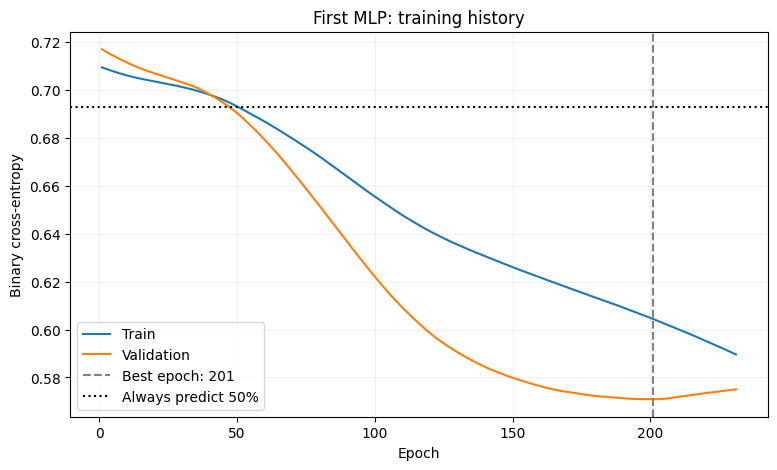

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train",
)

ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation",
)

ax.axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

ax.axhline(
    0.693147,
    color="black",
    linestyle=":",
    label="Always predict 50%",
)

ax.set(
    xlabel="Epoch",
    ylabel="Binary cross-entropy",
    title="First MLP: training history",
)

ax.legend()
ax.grid(alpha=0.2)
plt.show()

In [39]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    accuracy_score,
)

# 같은 입력·정답으로 회귀 모델 학습
baseline = LogisticRegression(
    C=1.0,
    max_iter=2000,
)

baseline.fit(
    X_train.detach().cpu().numpy(),
    y_train.detach().cpu().numpy(),
)

# Validation 예측
baseline_probs = baseline.predict_proba(
    X_val.detach().cpu().numpy()
)[:, 1]

model.eval()

with torch.no_grad():
    mlp_probs = torch.sigmoid(
        model(X_val).squeeze(-1)
    ).cpu().numpy()

y_true = y_val.detach().cpu().numpy()


def evaluate_probs(name, probabilities):
    return {
        "model": name,
        "log_loss": log_loss(
            y_true, probabilities, labels=[0, 1]
        ),
        "brier_score": brier_score_loss(
            y_true, probabilities
        ),
        "accuracy": accuracy_score(
            y_true, probabilities >= 0.5
        ),
    }


# 입력을 전혀 보지 않는 단순 기준도 함께 비교
train_win_rate = y_train.mean().item()

results = pd.DataFrame([
    evaluate_probs(
        "Always 50%",
        np.full(len(y_true), 0.5),
    ),
    evaluate_probs(
        "Train win-rate",
        np.full(len(y_true), train_win_rate),
    ),
    evaluate_probs("Logistic Regression", baseline_probs),
    evaluate_probs("MLP", mlp_probs),
])

display(results.round(4))

,model,log_loss,brier_score,accuracy
0,Always 50%,0.6931,0.2500,0.4557
1,Train win-rate,0.6898,0.2483,0.5443
2,Logistic Regression,0.5806,0.2004,0.6709
3,MLP,0.5709,0.1966,0.6709


In [40]:
# Test 정답
y_test_true = y_test.detach().cpu().numpy()

# Logistic Regression의 Test 예측
baseline_test_probs = baseline.predict_proba(
    X_test.detach().cpu().numpy()
)[:, 1]

# 선택된 epoch 201 MLP의 Test 예측
model.eval()

with torch.no_grad():
    mlp_test_probs = torch.sigmoid(
        model(X_test).squeeze(-1)
    ).cpu().numpy()


# 이전 함수와 달리 정답도 인자로 받아서,
# validation 정답을 실수로 사용하는 것을 방지
def evaluate_split(name, targets, probabilities):
    return {
        "model": name,
        "log_loss": log_loss(
            targets, probabilities, labels=[0, 1]
        ),
        "brier_score": brier_score_loss(
            targets, probabilities
        ),
        "accuracy": accuracy_score(
            targets, probabilities >= 0.5
        ),
    }


test_results = pd.DataFrame([
    evaluate_split(
        "Always 50%",
        y_test_true,
        np.full(len(y_test_true), 0.5),
    ),
    evaluate_split(
        "Train win-rate",
        y_test_true,
        np.full(len(y_test_true), train_win_rate),
    ),
    evaluate_split(
        "Logistic Regression",
        y_test_true,
        baseline_test_probs,
    ),
    evaluate_split(
        "MLP",
        y_test_true,
        mlp_test_probs,
    ),
])

print("Test 기간:", test["date"].min(), "→", test["date"].max())
print("Test 시리즈 수:", len(test))

display(test_results.round(4))

Test 기간: 2026-05-16 11:30:05 → 2026-09-12 05:21:16
Test 시리즈 수: 79


,model,log_loss,brier_score,accuracy
0,Always 50%,0.6931,0.2500,0.5570
1,Train win-rate,0.7009,0.2539,0.4430
2,Logistic Regression,0.7176,0.2608,0.4937
3,MLP,0.7165,0.2584,0.5443


In [41]:
summary = []

for name, split in [
    ("Train", train),
    ("Validation", val),
    ("Test", test),
]:
    summary.append({
        "split": name,
        "series": len(split),
        "start": split["date"].min(),
        "end": split["date"].max(),
        "team1_win_rate": split["result"].mean(),
        "bo5_ratio": split["is_bo5"].mean(),
    })

display(pd.DataFrame(summary))

# 각 구간의 원래 feature 평균 비교
display(
    pd.DataFrame({
        "Train": train[DIFF_COLS].mean(),
        "Validation": val[DIFF_COLS].mean(),
        "Test": test[DIFF_COLS].mean(),
    })
)

,split,series,start,end,team1_win_rate,bo5_ratio
0,Train,237,2025-01-15 08:09:30,2026-02-07 08:07:00,0.472574,0.143460
1,Validation,79,2026-02-07 10:09:22,2026-05-16 08:05:55,0.455696,0.139241
2,Test,79,2026-05-16 11:30:05,2026-09-12 05:21:16,0.556962,0.215190


,Train,Validation,Test
diff_roll_winrate,-0.008861,-0.078481,0.025316
diff_roll_golddiff15,56.261885,-450.346835,109.589873
diff_roll_firstdragon,0.032208,-0.055696,-0.035443
diff_roll_firstherald,-0.031294,0.025316,0.017722
diff_roll_firsttower,-0.026864,-0.035443,0.050633
diff_patch_winrate,-0.021688,-0.092793,-0.003189


In [42]:
# 원래 feature 공간에서 팀 순서를 뒤집기
swapped_val = val.copy()

# 통계 차이 6개만 부호 반전
swapped_val[DIFF_COLS] = -swapped_val[DIFF_COLS]

# is_bo5는 그대로 유지
X_val_swapped, _ = make_tensors(swapped_val)

model.eval()

with torch.no_grad():
    p_original = torch.sigmoid(
        model(X_val).squeeze(-1)
    )

    p_swapped = torch.sigmoid(
        model(X_val_swapped).squeeze(-1)
    )

# 이상적이면 모두 0
symmetry_error = (
    p_original + p_swapped - 1
).abs()

print("평균 순서 불일치:", symmetry_error.mean().item())
print("최대 순서 불일치:", symmetry_error.max().item())

display(
    pd.DataFrame({
        "P(A wins | A,B)": p_original.cpu().numpy(),
        "P(B wins | B,A)": p_swapped.cpu().numpy(),
        "합계": (p_original + p_swapped).cpu().numpy(),
        "불일치": symmetry_error.cpu().numpy(),
    }).head(10)
)

평균 순서 불일치: 0.08094348013401031
최대 순서 불일치: 0.26835906505584717


,"P(A wins | A,B)","P(B wins | B,A)",합계,불일치
0,0.467704,0.465870,0.933574,0.066426
1,0.517740,0.461521,0.979261,0.020739
2,0.464003,0.562979,1.026982,0.026982
3,0.429437,0.359063,0.788500,0.211500
4,0.418540,0.425096,0.843637,0.156363
5,0.521506,0.509054,1.030560,0.030560
6,0.460687,0.431281,0.891968,0.108032
7,0.582384,0.337356,0.919739,0.080261
8,0.432470,0.396330,0.828800,0.171200
9,0.589351,0.320162,0.909513,0.090487


In [43]:
# 앞 셀에서 계산한 양방향 확률 사용
symmetric_probs = (
    p_original + (1 - p_swapped)
) / 2

# 순서를 뒤집었을 때의 대칭 예측
symmetric_swapped_probs = (
    p_swapped + (1 - p_original)
) / 2

print(
    "대칭 처리 후 최대 불일치:",
    (
        symmetric_probs + symmetric_swapped_probs - 1
    ).abs().max().item()
)

# Validation에서 원래 예측과 비교
y_val_true = y_val.detach().cpu().numpy()

symmetry_results = pd.DataFrame([
    evaluate_split(
        "Original MLP",
        y_val_true,
        p_original.detach().cpu().numpy(),
    ),
    evaluate_split(
        "Symmetric MLP",
        y_val_true,
        symmetric_probs.detach().cpu().numpy(),
    ),
])

display(symmetry_results.round(4))

대칭 처리 후 최대 불일치: 5.960464477539063e-08


,model,log_loss,brier_score,accuracy
0,Original MLP,0.5709,0.1966,0.6709
1,Symmetric MLP,0.5623,0.1916,0.7215


### 실험 02 — 팀 순서 대칭 처리

- 모델: 실험 01의 MLP, 가중치 변경 없음
- 변경: 양방향 예측을 같은 팀 기준으로 변환한 후 평균
- 평가: validation 79개 시리즈
- Log loss: 0.5709 → 0.5623
- Brier score: 0.1966 → 0.1916
- Accuracy: 53/79 → 57/79
- 최대 순서 불일치: 약 5.96e-08
- 결론: 이 validation에서 일관성과 예측 지표가 개선됨
- 한계: 새로운 미래 데이터에서의 개선은 아직 확인하지 않음

## 실험 03 — 15분 골드 리드와 세트 승리의 관계

**질문:** 15분에 앞선 팀은 얼마나 자주 이기는가? 리드 크기에 따라 달라지는가?

- 기존 시간순 분리의 **train 60% 시리즈만** 사용한다. Validation/test 결과는 이 분석에 넣지 않는다.
- 한 세트의 Blue/Red 행을 둘 다 세면 중복이므로 **블루팀 한 행만** 사용한다.
- 첫 표는 블루팀 관점의 골드 차이와 승률, 두 번째 표는 진영과 무관한 **앞선 팀의 승률**이다.
- 이것은 **경기 도중 관측된 리드와 해당 세트 승패의 관계**다. 시리즈 시작 전 예측 성능이나 인과 효과가 아니다.
- 기존 셀의 메모리 상태와 무관하게 현재 로컬 원본과 feature 함수를 다시 읽는다. 모델은 재학습하지 않는다.


In [1]:
from pathlib import Path
import sys
import hashlib
import numpy as np
import pandas as pd
from IPython.display import display

lead_root = Path('/Users/seungyunmok/Developer/LOL_ML')
if str(lead_root) not in sys.path:
    sys.path.insert(0, str(lead_root))

from backend.training.process_lck_data import load_many_lck_team_games
from backend.training.feature_pipeline import build_featured_games, build_match_dataset

lead_sources = [
    lead_root / 'backend/data/raw' / f'{year}_LoL_esports_match_data_from_OraclesElixir.csv'
    for year in [2025, 2026]
]
lead_raw = load_many_lck_team_games(lead_sources)
lead_featured = build_featured_games(lead_raw)
lead_matches = build_match_dataset(lead_featured).sort_values(
    ['date', 'series_key']
).reset_index(drop=True)
lead_train = lead_matches.iloc[:int(len(lead_matches) * 0.6)].copy()

# 날짜만으로 자르지 않고, train의 series_key에 속한 모든 세트를 선택한다.
lead_games = lead_featured.loc[
    lead_featured['series_key'].isin(lead_train['series_key'])
    & lead_featured['side'].eq('Blue')
].copy()
assert not lead_games['gameid'].duplicated().any()
assert len(lead_games) == int(lead_train['game_count'].sum())
assert lead_games['result'].isin([0, 1]).all()
lead_missing = int(lead_games['golddiffat15'].isna().sum())
lead_valid = lead_games.dropna(subset=['golddiffat15']).copy()
assert np.isfinite(lead_valid['golddiffat15']).all()

print(f'전체 시리즈: {len(lead_matches)} / 분석 train 시리즈: {len(lead_train)}')
print(f"train 시리즈 시작일: {lead_train['date'].min()} → {lead_train['date'].max()}")
print(f'고유 세트: {len(lead_games)} / 15분 골드 결측 제외: {lead_missing} / 분석 세트: {len(lead_valid)}')
for source in lead_sources:
    print(source.name, 'SHA256:', hashlib.sha256(source.read_bytes()).hexdigest())


전체 시리즈: 395 / 분석 train 시리즈: 237
train 시리즈 시작일: 2025-01-15 08:09:30 → 2026-02-07 08:07:00
고유 세트: 633 / 15분 골드 결측 제외: 0 / 분석 세트: 633
2025_LoL_esports_match_data_from_OraclesElixir.csv SHA256: c9a158b9e0a965a47d31d3674c127a26f75e6c91a324bd1858e4784b1336214a
2026_LoL_esports_match_data_from_OraclesElixir.csv SHA256: 024330eb7a03e07c1aba55e17abf2e55f8e79e46e42e3f47389194173e59730a


In [2]:
# 구간은 결과를 보기 전에 정한 설명용 구간이다.
lead_bins = [-np.inf, -2000, -1000, 0, 1000, 2000, np.inf]
lead_labels = ['< -2000', '[-2000, -1000)', '[-1000, 0)', '[0, 1000)', '[1000, 2000)', '>= 2000']
lead_valid['blue_gold_bin'] = pd.cut(
    lead_valid['golddiffat15'], bins=lead_bins, labels=lead_labels, right=False
)
lead_blue_summary = lead_valid.groupby('blue_gold_bin', observed=False).agg(
    games=('gameid', 'size'),
    blue_wins=('result', 'sum'),
    mean_gold_diff=('golddiffat15', 'mean'),
)
lead_blue_summary['blue_win_rate'] = lead_blue_summary['blue_wins'] / lead_blue_summary['games']
print('블루팀 기준: 음수는 블루 열세, 양수는 블루 우위')
display(lead_blue_summary.round(4))

# 정확한 동률은 앞선 팀이 없으므로 리드 전환율에서 제외한다.
lead_non_tied = lead_valid.loc[lead_valid['golddiffat15'].ne(0)].copy()
lead_non_tied['lead_size'] = lead_non_tied['golddiffat15'].abs()
lead_non_tied['leader_won'] = np.where(
    lead_non_tied['golddiffat15'].gt(0),
    lead_non_tied['result'],
    1 - lead_non_tied['result'],
)
lead_non_tied['lead_bin'] = pd.cut(
    lead_non_tied['lead_size'], bins=[0, 1000, 2000, np.inf],
    labels=['0 < lead < 1000', '1000 <= lead < 2000', 'lead >= 2000'],
    right=False,
)
lead_summary = lead_non_tied.groupby('lead_bin', observed=False).agg(
    games=('gameid', 'size'), leader_wins=('leader_won', 'sum'),
)
lead_summary['comeback_wins'] = lead_summary['games'] - lead_summary['leader_wins']
lead_summary['leader_win_rate'] = lead_summary['leader_wins'] / lead_summary['games']
lead_summary['comeback_rate'] = lead_summary['comeback_wins'] / lead_summary['games']
assert int(lead_summary['games'].sum()) == len(lead_non_tied)
print('앞선 팀 기준: comeback은 15분 열세 팀이 최종 승리했다는 뜻')
display(lead_summary.round(4))
print('15분 골드 정확히 동률:', int(lead_valid['golddiffat15'].eq(0).sum()))
print(f"전체 비동률 세트의 리드 팀 승률: {lead_non_tied['leader_won'].mean():.2%}")


블루팀 기준: 음수는 블루 열세, 양수는 블루 우위


,games,blue_wins,mean_gold_diff,blue_win_rate
blue_gold_bin,,,,
< -2000,95,12,-3084.0947,0.1263
"[-2000, -1000)",90,24,-1469.1222,0.2667
"[-1000, 0)",121,55,-484.6446,0.4545
"[0, 1000)",136,77,508.7721,0.5662
"[1000, 2000)",90,68,1448.5333,0.7556
>= 2000,101,89,3346.8911,0.8812


앞선 팀 기준: comeback은 15분 열세 팀이 최종 승리했다는 뜻


,games,leader_wins,comeback_wins,leader_win_rate,comeback_rate
lead_bin,,,,,
0 < lead < 1000,257,143,114,0.5564,0.4436
1000 <= lead < 2000,180,134,46,0.7444,0.2556
lead >= 2000,196,172,24,0.8776,0.1224


15분 골드 정확히 동률: 0
전체 비동률 세트의 리드 팀 승률: 70.93%


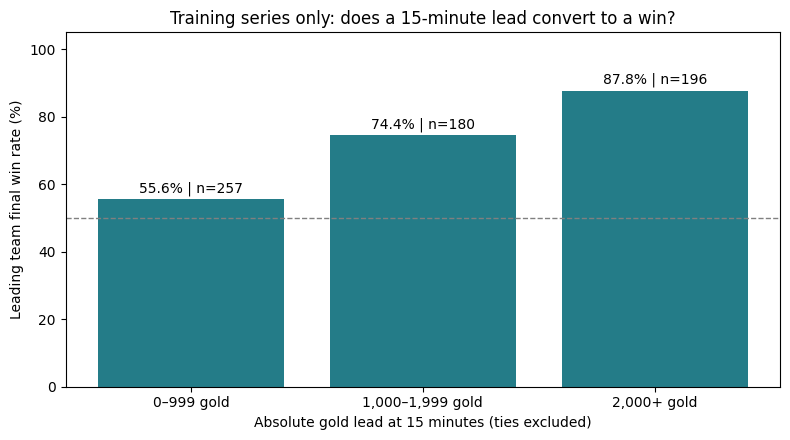

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
lead_positions = np.arange(len(lead_summary))
lead_rates = lead_summary['leader_win_rate'].to_numpy() * 100
ax.bar(lead_positions, lead_rates, color='#247c88')
ax.set_xticks(lead_positions, ['0–999 gold', '1,000–1,999 gold', '2,000+ gold'])
ax.set_ylim(0, 105)
ax.set_xlabel('Absolute gold lead at 15 minutes (ties excluded)')
ax.set_ylabel('Leading team final win rate (%)')
ax.set_title('Training series only: does a 15-minute lead convert to a win?')
ax.axhline(50, color='gray', linestyle='--', linewidth=1)
for pos, rate, count in zip(lead_positions, lead_rates, lead_summary['games']):
    if np.isfinite(rate):
        ax.text(pos, rate + 2, f'{rate:.1f}% | n={count}', ha='center')
fig.tight_layout()
plt.show()


## 실험 04 — 시간순 검증: feature 설정별 비교 (리팩토링)

현재 비교: **기존 7개 입력 vs 기존 7개 + 과거 15분 1000골드 이상 리드율 차이 = 8개 입력**.
단순 양수 리드율은 입력에서 제외한다. `ts_groups` 목록으로 비교할 feature를 지정한다.

셀 구성: ① imports ② 데이터와 feature 설정 ③ Tensor·대칭 예측 함수 ④ 학습·시간순 평가 함수 ⑤ 실행 및 결과.

- 기존 9개 입력 실험의 코드와 출력은 [원본 기록](experiments/04_lead9_original.ipynb)에 보존했다.
- 이전과 같은 개발 316시리즈, 날짜별 3개 expanding fold, 과거 내부 20% early stopping, seed 42/43/44를 사용한다.
- 최대 500 epochs, patience 30, Adam 0.001, 16→8 MLP 및 양방향 확률 평균을 유지한다.
- 마지막 test 79개는 이번 비교에서 사용하지 않는다. 평가 label로 epoch를 선택하지 않는다.
- rolling은 과거 5세트만 사용하고 시리즈 첫 세트 시점의 feature를 선택한다. 평가 기간 내 앞선 경기 결과는 뒤 경기 입력에 반영되는 순차 예측이다.
- 개발 결과이며 미래 성능의 확정 증거가 아니다. seed 반복은 독립 경기 수를 늘리지 않는다.


In [1]:
from pathlib import Path
import sys
from copy import deepcopy
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
from IPython.display import display

ts_root = Path('/Users/seungyunmok/Developer/LOL_ML')
if str(ts_root) not in sys.path:
    sys.path.insert(0, str(ts_root))
from backend.training.process_lck_data import load_many_lck_team_games
from backend.training.feature_pipeline import build_featured_games, build_match_dataset, DIFF_COLS



In [2]:
ts_raw = load_many_lck_team_games([
    ts_root / 'backend/data/raw' / f'{year}_LoL_esports_match_data_from_OraclesElixir.csv'
    for year in [2025, 2026]
])
ts_games = build_featured_games(ts_raw).sort_values(['teamname', 'date', 'gameid']).copy()
# 결측은 False로 바꾸지 않는다. 이 실험 데이터에는 결측이 없어야 한다.
assert ts_games['golddiffat15'].notna().all()
for name, threshold in [('lead15_rate', 0), ('strong_lead15_rate', 1000)]:
    indicator = (ts_games['golddiffat15'] > 0) if threshold == 0 else (ts_games['golddiffat15'] >= threshold)
    ts_games[name + '_indicator'] = indicator.astype(float)
    ts_games[name] = ts_games.groupby('teamname')[name + '_indicator'].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0.5)  # 과거 기록이 없는 경우의 공통 초기값. 실제 리그 빈도의 추정값은 아니다.

ts_matches = build_match_dataset(ts_games).sort_values(['date', 'series_key']).reset_index(drop=True)
ts_first = ts_games.sort_values(['date', 'gameid']).drop_duplicates(['series_key', 'teamname']).set_index(['series_key', 'teamname'])
ts_new_cols = []
for name in ['lead15_rate', 'strong_lead15_rate']:
    column = 'diff_' + name
    ts_new_cols.append(column)
    ts_matches[column] = [
        float(ts_first.loc[(row.series_key, row.team1), name] - ts_first.loc[(row.series_key, row.team2), name])
        for row in ts_matches.itertuples()
    ]
ts_matches['is_bo5'] = ts_matches['best_of'].eq(5).astype(float)
ts_dev = ts_matches.iloc[:int(len(ts_matches) * 0.8)].copy()
ts_dev['day'] = ts_dev['date'].dt.normalize()
ts_days = np.sort(ts_dev['day'].unique())
ts_groups = {'base_7': list(DIFF_COLS), 'strong_lead_8': list(DIFF_COLS) + ['diff_strong_lead15_rate']}
print(f'개발 시리즈 {len(ts_dev)}개 / 제외한 마지막 구간 {len(ts_matches)-len(ts_dev)}개')
display(ts_dev[['date', *ts_new_cols]].head())



개발 시리즈 316개 / 제외한 마지막 구간 79개


,date,diff_lead15_rate,diff_strong_lead15_rate
0,2025-01-15 08:09:30,0.0,0.0
1,2025-01-15 11:26:48,0.0,0.0
2,2025-01-16 08:09:06,0.0,0.0
3,2025-01-16 11:11:06,0.0,0.0
4,2025-01-17 08:08:25,0.0,0.0


In [3]:
def ts_arrays(frame, columns, scale, reverse=False):
    values = frame[columns].to_numpy(dtype=float)
    if reverse:
        values = -values
    x = np.column_stack([scale.transform(values), frame['is_bo5'].to_numpy()])
    return torch.tensor(x, dtype=torch.float32)

def ts_probs(net, forward, reverse):
    return (torch.sigmoid(net(forward).squeeze(-1)) + 1 - torch.sigmoid(net(reverse).squeeze(-1))) / 2



In [4]:
# 학습 함수: 외부 평가 구간을 보지 않고 inner validation으로 epoch 선택
TS_SEEDS = [42, 43, 44]
TS_MAX_EPOCHS = 500
TS_PATIENCE = 30
TS_LR = 0.001

def ts_fit_predict(fit, stop, future, columns, seed):
    scale = StandardScaler().fit(fit[columns].to_numpy(dtype=float))
    xf = ts_arrays(fit, columns, scale)
    xs, xsr = ts_arrays(stop, columns, scale), ts_arrays(stop, columns, scale, True)
    xt, xtr = ts_arrays(future, columns, scale), ts_arrays(future, columns, scale, True)
    yf = torch.tensor(fit['result'].to_numpy(), dtype=torch.float32)
    ys = torch.tensor(stop['result'].to_numpy(), dtype=torch.float32)
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(len(columns)+1,16), nn.ReLU(), nn.Linear(16,8), nn.ReLU(), nn.Linear(8,1))
    opt = torch.optim.Adam(net.parameters(), lr=TS_LR)
    loss_fn = nn.BCEWithLogitsLoss()
    best, saved, best_epoch, stale = float('inf'), None, 0, 0
    for epoch in range(1, TS_MAX_EPOCHS+1):
        net.train()
        opt.zero_grad()
        loss = loss_fn(net(xf).squeeze(-1), yf)
        loss.backward()
        opt.step()
        net.eval()
        with torch.no_grad():
            pstop = ts_probs(net, xs, xsr).clamp(1e-7,1-1e-7)
            stop_loss = nn.functional.binary_cross_entropy(pstop, ys).item()
        if stop_loss < best:
            best, saved, best_epoch, stale = stop_loss, deepcopy(net.state_dict()), epoch, 0
        else:
            stale += 1
        if stale >= TS_PATIENCE:
            break
    net.load_state_dict(saved)
    net.eval()
    with torch.no_grad():
        pred = ts_probs(net, xt, xtr).numpy()
    return pred, best_epoch


def ts_run_experiment(dev, groups):
    days = np.sort(dev['day'].unique())
    scores, predictions, fold_info = [], [], []
    for fold, (past_idx, future_idx) in enumerate(TimeSeriesSplit(n_splits=3).split(days), 1):
        past_days, future_days = days[past_idx], days[future_idx]
        inner_cut = int(len(past_days)*0.8)
        fit = dev[dev['day'].isin(past_days[:inner_cut])]
        stop = dev[dev['day'].isin(past_days[inner_cut:])]
        future = dev[dev['day'].isin(future_days)]
        assert fit['date'].max() < stop['date'].min() < future['date'].min()
        fold_info.append({'fold':fold,'fit':len(fit),'early_stop':len(stop),'future':len(future),
                          'future_start':future['date'].min(),'future_end':future['date'].max()})
        for variant, columns in groups.items():
            for seed in TS_SEEDS:
                pred, epoch = ts_fit_predict(fit, stop, future, columns, seed)
                truth = future['result'].to_numpy()
                scores.append({'fold':fold,'variant':variant,'seed':seed,'n':len(future),'epoch':epoch,
                               'log_loss':log_loss(truth,pred,labels=[0,1]),'brier':brier_score_loss(truth,pred),
                               'accuracy':accuracy_score(truth,pred>=0.5)})
                for row, probability in zip(future.itertuples(), pred):
                    predictions.append({'fold':fold,'variant':variant,'seed':seed,'series_key':row.series_key,
                                        'date':row.date,'y':int(row.result),'p':float(probability)})
        print(f'fold {fold} 완료')
    return pd.DataFrame(scores), pd.DataFrame(predictions), pd.DataFrame(fold_info)


In [5]:
ts_scores, ts_predictions, ts_fold_info = ts_run_experiment(ts_dev, ts_groups)
print('기간 및 표본 수')
display(pd.DataFrame(ts_fold_info))
print('fold별 3개 seed 평균 (seed 반복은 독립 경기 추가가 아님)')
display(ts_scores.groupby(['fold','variant'])[['log_loss','brier','accuracy']].mean().round(4))
ts_overall = []
for (variant, seed), rows in ts_predictions.groupby(['variant','seed']):
    ts_overall.append({'variant':variant,'seed':seed,'n':len(rows),
                       'log_loss':log_loss(rows['y'],rows['p'],labels=[0,1]),
                       'brier':brier_score_loss(rows['y'],rows['p']),
                       'accuracy':accuracy_score(rows['y'],rows['p']>=0.5)})
ts_overall = pd.DataFrame(ts_overall)
print('미래 평가 행을 합친 성능: seed별 결과 및 평균')
display(ts_overall.round(4))
display(ts_overall.groupby('variant')[['log_loss','brier','accuracy']].agg(['mean','std']).round(4))
print('50% 확률 기준 log loss:', np.log(2), '/ Brier: 0.25')


fold 1 완료


fold 2 완료
fold 3 완료
기간 및 표본 수


,fold,fit,early_stop,future,future_start,future_end
0,1,64,20,84,2025-05-03 06:07:27,2025-08-14 10:09:25
1,2,132,36,70,2025-08-15 08:06:45,2026-02-07 10:09:22
2,3,198,40,78,2026-02-08 08:06:06,2026-05-16 08:05:55


fold별 3개 seed 평균 (seed 반복은 독립 경기 추가가 아님)


log_loss   brier  accuracy
fold variant                                  
1    base_7           0.6927  0.2499    0.4246
     strong_lead_8    0.6943  0.2507    0.4405
2    base_7           0.7442  0.2711    0.4714
     strong_lead_8    0.7012  0.2540    0.4714
3    base_7           0.6469  0.2273    0.6880
     strong_lead_8    0.6588  0.2329    0.7179

미래 평가 행을 합친 성능: seed별 결과 및 평균


,variant,seed,n,log_loss,brier,accuracy
0,base_7,42,232,0.6763,0.2417,0.4957
1,base_7,43,232,0.7176,0.2591,0.5560
2,base_7,44,232,0.6846,0.2452,0.5302
3,strong_lead_8,42,232,0.6845,0.2457,0.5000
4,strong_lead_8,43,232,0.6837,0.2453,0.5603
5,strong_lead_8,44,232,0.6851,0.2460,0.5690


log_loss           brier         accuracy        
                  mean     std    mean     std     mean     std
variant                                                        
base_7          0.6928  0.0219  0.2487  0.0092   0.5273  0.0303
strong_lead_8   0.6844  0.0007  0.2457  0.0003   0.5431  0.0376

50% 확률 기준 log loss: 0.6931471805599453 / Brier: 0.25


## 실험 05 — 10/15/20분 리드율 + 첫 바론 획득률 비교

- 각 모델: 기존 7개 입력 + 해당 시점 1,000골드 이상 리드율 차이 + 첫 바론 획득률 차이 = 9개.
- 기존 7개에는 15분 평균 골드 차이가 유지된다. 시간별 지표의 단독 비교가 아니라 기존 입력에 추가하는 비교다.
- 최근 5세트, shift(1), 시리즈 첫 세트의 과거 정보만 사용한다. 첫 바론 비율의 분모는 바론이 없는 경기를 포함한 최근 5세트다.
- firstbaron 결측 중 양 팀 바론 수가 0인 경우만 미획득(0)으로 처리. 그 외 결측은 실행을 중단한다.
- 실험 04 함수 재사용: 같은 3개 시간순 fold, seed 42/43/44, 내부 early stopping, 대칭 예측. 마지막 79개 test는 평가하지 않는다.
- 기본 7개를 참조로 함께 실행한다. 첫 바론 자체의 기여를 분리하는 ablation은 이 비교에 포함하지 않는다.
- 이전 test 결과는 이미 열람했으므로 마지막 구간도 완전히 새로운 미관측 검증 자료라고 볼 수 없다.
- 아래 실행 전 실험 04의 imports 및 함수 정의 셀을 실행한다.


In [4]:
# 원본에서 필요한 추가 컬럼을 읽고, 검증된 기존 로더 결과에 결합한다.
e5_paths = [ts_root / 'backend/data/raw' / f'{year}_LoL_esports_match_data_from_OraclesElixir.csv' for year in [2025, 2026]]
e5_raw = load_many_lck_team_games(e5_paths)
# The production loader now includes some of the additional columns.
e5_raw = e5_raw.drop(columns=['golddiffat10', 'firstbaron', 'barons', 'opp_barons'], errors='ignore')
e5_extra = []
for path in e5_paths:
    rows = pd.read_csv(path, usecols=['gameid','side','league','position','datacompleteness',
        'golddiffat10','golddiffat20','firstbaron','barons','opp_barons'], low_memory=False)
    rows = rows.loc[rows['league'].eq('LCK') & rows['position'].eq('team') & rows['datacompleteness'].eq('complete')]
    e5_extra.append(rows.drop(columns=['league','position','datacompleteness']))
e5_raw = e5_raw.merge(pd.concat(e5_extra), on=['gameid','side'], how='left', validate='one_to_one')
e5_missing = e5_raw['firstbaron'].isna()
e5_no_baron = e5_raw['barons'].eq(0) & e5_raw['opp_barons'].eq(0)
assert not (e5_missing & ~e5_no_baron).any(), 'Unknown firstbaron missingness'
print('바론 없는 경기로 확인된 결측 팀 행:', int(e5_missing.sum()))
e5_raw.loc[e5_missing & e5_no_baron, 'firstbaron'] = 0
assert e5_raw['firstbaron'].isin([0,1]).all()
assert e5_raw[['golddiffat10','golddiffat15','golddiffat20']].notna().all().all()
e5_games = build_featured_games(e5_raw).sort_values(['teamname','date','gameid']).copy()
e5_rates = []
for minute in [10,15,20]:
    name = f'strong_lead{minute}_rate'
    e5_games[name + '_indicator'] = e5_games[f'golddiffat{minute}'].ge(1000).astype(float)
    e5_rates.append((name, name + '_indicator'))
e5_rates.append(('firstbaron_rate','firstbaron'))
for name, source in e5_rates:
    e5_games[name] = e5_games.groupby('teamname')[source].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0.5)
e5_matches = build_match_dataset(e5_games).sort_values(['date','series_key']).reset_index(drop=True)
e5_first = e5_games.sort_values(['date','gameid']).drop_duplicates(['series_key','teamname']).set_index(['series_key','teamname'])
for name, _ in e5_rates:
    e5_matches['diff_' + name] = [
        float(e5_first.loc[(r.series_key,r.team1),name] - e5_first.loc[(r.series_key,r.team2),name])
        for r in e5_matches.itertuples()]
e5_matches['is_bo5'] = e5_matches['best_of'].eq(5).astype(float)
e5_dev = e5_matches.iloc[:int(len(e5_matches)*0.8)].copy()
e5_dev['day'] = e5_dev['date'].dt.normalize()
e5_groups = {'base_7':list(DIFF_COLS)}
for minute in [10,15,20]:
    e5_groups[f'lead{minute}_baron_9'] = list(DIFF_COLS) + [f'diff_strong_lead{minute}_rate','diff_firstbaron_rate']
assert np.isfinite(e5_dev[list(dict.fromkeys(c for cols in e5_groups.values() for c in cols))]).all().all()
print('개발 시리즈:',len(e5_dev),' / 이번 평가에서 제외:',len(e5_matches)-len(e5_dev))
display(pd.DataFrame({'model':list(e5_groups),'input_count':[len(c)+1 for c in e5_groups.values()]}))


바론 없는 경기로 확인된 결측 팀 행: 50


개발 시리즈: 316  / 이번 평가에서 제외: 79


,model,input_count
0,base_7,7
1,lead10_baron_9,9
2,lead15_baron_9,9
3,lead20_baron_9,9


In [5]:
e5_scores, e5_predictions, e5_folds = ts_run_experiment(e5_dev, e5_groups)
display(e5_folds)
print('Fold별 seed 평균')
display(e5_scores.groupby(['fold','variant'])[['log_loss','brier','accuracy']].mean().round(4))
e5_overall = []
for (variant, seed), rows in e5_predictions.groupby(['variant','seed']):
    assert not rows['series_key'].duplicated().any()
    e5_overall.append({'variant':variant,'seed':seed,'n':len(rows),
        'log_loss':log_loss(rows['y'],rows['p'],labels=[0,1]),
        'brier':brier_score_loss(rows['y'],rows['p']),
        'accuracy':accuracy_score(rows['y'],rows['p']>=0.5)})
e5_overall = pd.DataFrame(e5_overall)
print('전체 평가 시리즈: seed별 지표의 평균과 표준편차 (ensemble 아님)')
display(e5_overall.groupby('variant')[['log_loss','brier','accuracy']].agg(['mean','std']).round(4))
print('50% 고정 확률 기준: log_loss =',np.log(2),', Brier = 0.25')


fold 1 완료


fold 2 완료


fold 3 완료


,fold,fit,early_stop,future,future_start,future_end
0,1,64,20,84,2025-05-03 06:07:27,2025-08-14 10:09:25
1,2,132,36,70,2025-08-15 08:06:45,2026-02-07 10:09:22
2,3,198,40,78,2026-02-08 08:06:06,2026-05-16 08:05:55


Fold별 seed 평균


log_loss   brier  accuracy
fold variant                                   
1    base_7            0.6927  0.2499    0.4246
     lead10_baron_9    0.6896  0.2486    0.5079
     lead15_baron_9    0.6809  0.2442    0.5397
     lead20_baron_9    0.6901  0.2486    0.4405
2    base_7            0.7442  0.2711    0.4714
     lead10_baron_9    0.6893  0.2483    0.5000
     lead15_baron_9    0.7148  0.2601    0.4810
     lead20_baron_9    0.7142  0.2603    0.4619
3    base_7            0.6469  0.2273    0.6880
     lead10_baron_9    0.6364  0.2221    0.7051
     lead15_baron_9    0.6458  0.2266    0.7051
     lead20_baron_9    0.6275  0.2178    0.7222

전체 평가 시리즈: seed별 지표의 평균과 표준편차 (ensemble 아님)


log_loss           brier         accuracy        
                   mean     std    mean     std     mean     std
variant                                                         
base_7           0.6928  0.0219  0.2487  0.0092   0.5273  0.0303
lead10_baron_9   0.6716  0.0020  0.2396  0.0011   0.5718  0.0174
lead15_baron_9   0.6793  0.0108  0.2431  0.0050   0.5776  0.0283
lead20_baron_9   0.6763  0.0037  0.2418  0.0017   0.5417  0.0539

50% 고정 확률 기준: log_loss = 0.6931471805599453 , Brier = 0.25


## 실험 06 — 기존 후보 10개의 조합 탐색

- 후보: 기존 통계 차이 6개 + 10/15/20분 1,000골드 리드율 차이 + 첫 바론 획득률 차이. is_bo5는 고정.
- 원본 165개 전체를 탐색하는 실험이 아니다. MLP 구조/학습 설정/최근 5세트 창은 고정한다.
- 개발 구간의 마지막 outer fold(78시리즈)를 조합 선택에서 제외. 앞선 238시리즈 안에서 3개 시간순 fold, seed 42/43/44 평균 log loss로 탐색한다.
- 단일 피처부터 전진 선택 후 후진 제거. 개선 최소 0.001; 전 조합 최적 보장은 없다. 기존 7개, 이전 우수 9개, 전체 11개도 후보로 비교한다.
- 선택한 조합을 고정한 후 뒤 78시리즈에서 비교한다. 이 구간은 이전 실험에서 이미 열람했으므로 독립 최종 test라고 부르지 않는다. 마지막 79시리즈는 실행에 사용하지 않는다.
- 선택 점수는 다중 비교로 낙관적일 수 있으며, 피처 포함/제외는 인과 효과가 아니다.
- 실행 전 실험 04 함수 정의와 실험 05 데이터 준비 셀 필요.


In [5]:
from contextlib import redirect_stdout
import io
from itertools import combinations

e6_candidates = list(DIFF_COLS) + [f'diff_strong_lead{m}_rate' for m in [10,15,20]] + ['diff_firstbaron_rate']
e6_days = np.sort(e5_dev['day'].unique())
e6_past_idx, e6_future_idx = list(TimeSeriesSplit(n_splits=3).split(e6_days))[-1]
e6_search = e5_dev[e5_dev['day'].isin(e6_days[e6_past_idx])].copy()
e6_confirm = e5_dev[e5_dev['day'].isin(e6_days[e6_future_idx])].copy()
assert e6_search.date.max() < e6_confirm.date.min()
e6_cache = {}
e6_trace = []

def e6_evaluate(columns):
    key = tuple(c for c in e6_candidates if c in columns)
    if key not in e6_cache:
        with redirect_stdout(io.StringIO()):
            scores, preds, folds = ts_run_experiment(e6_search, {'candidate':list(key)})
        per_seed = [log_loss(g.y,g.p,labels=[0,1]) for _,g in preds.groupby('seed')]
        e6_cache[key] = {'columns':list(key), 'input_count':len(key)+1,
            'log_loss':float(np.mean(per_seed)), 'seed_std':float(np.std(per_seed,ddof=1))}
    return e6_cache[key]['log_loss']

# 최소 한 개 통계 피처 + is_bo5부터 시작. 기준 세 조합도 탐색에 포함.
e6_reference = {'base_7':list(DIFF_COLS), 'lead10_baron_9':e5_groups['lead10_baron_9'], 'all_11':e6_candidates}
for cols in e6_reference.values():
    e6_evaluate(cols)
e6_selected = min(([c] for c in e6_candidates), key=e6_evaluate)
e6_current = e6_evaluate(e6_selected)
e6_trace.append({'step':'single','columns':list(e6_selected),'log_loss':e6_current})
while len(e6_selected) < len(e6_candidates):
    options = [e6_selected+[c] for c in e6_candidates if c not in e6_selected]
    winner = min(options,key=e6_evaluate)
    score = e6_evaluate(winner)
    if e6_current-score < 0.001:
        break
    e6_selected,e6_current = winner,score
    e6_trace.append({'step':'add','columns':list(winner),'log_loss':score})
    print('추가:',len(winner),'stats / loss:',round(score,4), flush=True)
# 전체 후보에서 제거하는 탐색도 수행해 다른 조합을 비교한다.
e6_backward = list(e6_candidates)
e6_back_loss = e6_evaluate(e6_backward)
while len(e6_backward)>1:
    options = [[c for c in e6_backward if c!=remove] for remove in e6_backward]
    winner = min(options,key=e6_evaluate)
    score = e6_evaluate(winner)
    if e6_back_loss-score < 0.001:
        break
    e6_backward,e6_back_loss = winner,score
    e6_trace.append({'step':'remove','columns':list(winner),'log_loss':score})
    print('제거:',len(winner),'stats / loss:',round(score,4),flush=True)
e6_ranking = pd.DataFrame(e6_cache.values()).sort_values(['log_loss','input_count']).reset_index(drop=True)
e6_selected = e6_ranking.iloc[0]['columns']
print('탐색 조합 수:',len(e6_cache),' / 탐색 시리즈:',len(e6_search),' / 후속 확인:',len(e6_confirm))
print('선택:',e6_selected,'+ is_bo5')
display(e6_ranking.head(10))
display(pd.DataFrame(e6_trace))


추가: 2 stats / loss: 0.6687


제거: 9 stats / loss: 0.6809


탐색 조합 수: 49  / 탐색 시리즈: 238  / 후속 확인: 78
선택: ['diff_roll_winrate', 'diff_roll_golddiff15'] + is_bo5


,columns,input_count,log_loss,seed_std
0,"[diff_roll_winrate, diff_roll_golddiff15]",3,0.668742,0.005057
1,"[diff_roll_winrate, diff_strong_lead20_rate]",3,0.671761,0.005940
2,"[diff_roll_winrate, diff_patch_winrate]",3,0.672793,0.006252
3,"[diff_roll_winrate, diff_roll_golddiff15, diff...",4,0.674438,0.004732
4,"[diff_roll_winrate, diff_roll_golddiff15, diff...",4,0.674564,0.004127
5,"[diff_roll_winrate, diff_strong_lead15_rate]",3,0.674750,0.004924
6,[diff_roll_winrate],2,0.676230,0.013606
7,"[diff_roll_winrate, diff_roll_golddiff15, diff...",4,0.678015,0.000202
8,"[diff_roll_winrate, diff_roll_golddiff15, diff...",4,0.678760,0.005327
9,"[diff_roll_winrate, diff_roll_golddiff15, diff...",4,0.679460,0.005420


,step,columns,log_loss
0,single,[diff_roll_winrate],0.676230
1,add,"[diff_roll_winrate, diff_roll_golddiff15]",0.668742
2,remove,"[diff_roll_winrate, diff_roll_golddiff15, diff...",0.680859


In [6]:
# 조합은 이미 고정했다. 이 표의 결과를 보고 다시 선택하지 않는다.
e6_past_days = np.sort(e6_search.day.unique())
e6_cut = int(len(e6_past_days)*0.8)
e6_fit = e6_search[e6_search.day.isin(e6_past_days[:e6_cut])]
e6_stop = e6_search[e6_search.day.isin(e6_past_days[e6_cut:])]
e6_confirm_rows = []
e6_prediction_rows = []
for variant, cols in {**e6_reference,'selected':e6_selected}.items():
    for seed in TS_SEEDS:
        pred, epoch = ts_fit_predict(e6_fit,e6_stop,e6_confirm,cols,seed)
        y = e6_confirm.result.to_numpy()
        e6_confirm_rows.append({'variant':variant,'seed':seed,'epoch':epoch,
            'log_loss':log_loss(y,pred,labels=[0,1]),'brier':brier_score_loss(y,pred),
            'accuracy':accuracy_score(y,pred>=0.5)})
        for row,p in zip(e6_confirm.itertuples(),pred):
            e6_prediction_rows.append({'variant':variant,'seed':seed,'series_key':row.series_key,'y':row.result,'p':float(p)})
e6_confirmation = pd.DataFrame(e6_confirm_rows)
print('후속 구간:',e6_confirm.date.min(),'→',e6_confirm.date.max())
display(e6_confirmation.groupby('variant')[['log_loss','brier','accuracy']].agg(['mean','std']).round(4))
# 전체 탐색 및 선택 기록을 보존한다.
e6_dir = ts_root / 'notebook/experiments/06_feature_search'
e6_dir.mkdir(parents=True,exist_ok=True)
e6_ranking.to_json(e6_dir/'search_ranking.json',orient='records',indent=2)
e6_confirmation.to_csv(e6_dir/'confirmation_scores.csv',index=False)
pd.DataFrame(e6_prediction_rows).to_csv(e6_dir/'confirmation_predictions.csv',index=False)


후속 구간: 2026-02-08 08:06:06 → 2026-05-16 08:05:55


log_loss           brier         accuracy        
                   mean     std    mean     std     mean     std
variant                                                         
all_11           0.6585  0.0095  0.2328  0.0047   0.6838  0.0296
base_7           0.6469  0.0311  0.2273  0.0152   0.6880  0.0323
lead10_baron_9   0.6364  0.0154  0.2221  0.0074   0.7051  0.0339
selected         0.6260  0.0056  0.2173  0.0026   0.6795  0.0000

### 실험 06 결과 해석

49개 조합 중 과거 시간순 검증 log loss가 가장 낮은 조합은 **최근 5세트 승률 차이 + 최근 5세트 평균 15분 골드 차이 + is_bo5**였다 (선택 점수 0.6687).

조합 선택에서 제외한 후속 78시리즈에서 seed 평균 log loss 0.6260, Brier 0.2173, 정확도 67.95%. 기존 7개는 0.6469 / 0.2273 / 68.80%, 10분 리드율+바론 추가 모델은 0.6364 / 0.2221 / 70.51%였다.

확률 손실 기준 개선이지만 정확도는 낮다. 이 실험의 목적 지표는 사전에 정한 log loss다. 작은 표본·제한된 탐색·기존에 열람한 개발 구간이므로 전역 최적이나 미래 성능을 보장하지 않는다. 제외된 피처가 항상 해롭다는 결론도 아니다. 원래 마지막 79개 구간은 이번 탐색/확인에 사용하지 않았다.


## 실험 07 — 이전 후보 전체 동일 조건 재비교

- 이전 49조합 및 초기 실험의 추가 조합을 중복 제거해 비교. 모든 MLP는 16→8 은닉층, seed 42/43/44, 동일 early stopping 및 입력 순서 대칭 처리.
- 예측 확률을 세 seed에서 평균한 ensemble로 정확도 순위를 비교. 동률은 log loss로 정렬. 개별 seed 점수도 별도 저장.
- 개발 3개 fold 232시리즈 + 뒤 79시리즈 = 서로 겹치지 않는 311시리즈. 모든 학습/early stopping 구간은 해당 평가 구간보다 과거다.
- 여러 조합 선택에 재사용한 데이터다. 미관측 test나 확정 미래 성능이 아니다. 초기 84시리즈는 학습에 필요하므로 평가에서 제외.
- 전체 정확도로 선택하며 최근 구간은 별도로 보고한다. 기존 70.51%는 특정 fold의 seed 평균으로, 이 표의 전체 ensemble 정확도와 다르다.


In [ ]:
from pathlib import Path
import pandas as pd
comparison_dir = Path('/Users/seungyunmok/Developer/LOL_ML/notebook/experiments/07_full_comparison')
comparison = pd.read_csv(comparison_dir / 'ensemble_scores.csv')
display(comparison[comparison.period.eq('all_311')].sort_values(['accuracy','log_loss'], ascending=[False,True]))

variant,period,n,correct,accuracy,roc_auc,log_loss,brier_score,probability_min,probability_max
search_20,all_311,311,194,0.623794,0.636751,0.671458,0.239448,0.192194,0.780401
search_23,all_311,311,194,0.623794,0.633255,0.673780,0.239410,0.164030,0.845363
search_06,all_311,311,192,0.617363,0.627421,0.675751,0.240901,0.149441,0.851621
minimal_3,all_311,311,191,0.614148,0.622435,0.671585,0.239427,0.197652,0.828877
search_21,all_311,311,190,0.610932,0.611118,0.690173,0.247626,0.175829,0.882965
search_07,all_311,311,188,0.604502,0.622373,0.677776,0.241830,0.177488,0.850445
search_04,all_311,311,187,0.601286,0.621731,0.671176,0.239200,0.196203,0.844382
search_05,all_311,311,186,0.598071,0.627524,0.670295,0.238476,0.204335,0.841661
search_02,all_311,311,185,0.594855,0.618628,0.674413,0.240592,0.207130,0.846584
search_11,all_311,311,185,0.594855,0.615070,0.674588,0.240606,0.205044,0.800618
